# Trump Tweet Event Study: Industry Daily Volatility — LONG-TERM (v11)

## Methodology: ΔRV = RV_post − RV_pre  (Symmetric 5-Day Windows)

| Parameter | Value |
|---|---|
| **Resolution** | Daily bars (t = trading-day offset from tweet) |
| **Pre window** | t ∈ [−5, −1]  (5 trading days before tweet) → $RV_{pre} = \sum r_t^2$ |
| **Post window** | t ∈ [+1, +5]  (5 trading days after tweet)  → $RV_{post} = \sum r_t^2$ |
| **Display window** | t ∈ [−5, +5]  (11 bars) |
| **Effect measure** | $\Delta RV = RV_{post} - RV_{pre}$ |
| **Industries** | 10 sectors |

### ΔRV Formula

$$RV_{pre} = \sum_{d=-5}^{-1} r_d^2 \qquad (5 \text{ days})$$
$$RV_{post} = \sum_{d=+1}^{+5} r_d^2 \qquad (5 \text{ days})$$
$$\Delta RV = RV_{post} - RV_{pre}$$

---

## 0. Setup & Imports

In [1]:
import os
import re
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

# ── Global plot style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.family'       : 'sans-serif',
    'font.size'         : 10,
    'axes.titlesize'    : 12,
    'axes.labelsize'    : 10,
    'legend.fontsize'   : 8,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})
PALETTE = plt.cm.tab10(np.linspace(0, 1, 10))

print("✅ Libraries loaded.")
print("   Time unit : trading HOUR  (09:30–14:30 ET, 6 bars/day)")
print("   After-hours tweets → h=0 = next trading open (09:30 ET)")


✅ Libraries loaded.
   Time unit : trading HOUR  (09:30–14:30 ET, 6 bars/day)
   After-hours tweets → h=0 = next trading open (09:30 ET)


---
## 1. Configuration

> **Edit only this cell** to update file paths or parameters.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# FILE PATHS
# ══════════════════════════════════════════════════════════════════
DATA_DIR = "EVENT STUDY PANELS BY SINGLE INDUSTRY"


# ══════════════════════════════════════════════════════════════════
# WINDOW PARAMETERS  (t = trading-day offset from tweet day)
# ══════════════════════════════════════════════════════════════════
PRE_T_START  = -5   # pre-event window start  (inclusive)
PRE_T_END    = -1   # pre-event window end    (inclusive)
POST_T_START =  1   # post-event window start (t=0 excluded — tweet day itself)
POST_T_END   =  5   # post-event window end   (inclusive)
DISPLAY_WIN  =  5   # display range: ±DISPLAY_WIN days

# ── Derived ──────────────────────────────────────────────────────
T_MIN  = -DISPLAY_WIN
T_MAX  =  DISPLAY_WIN
T_VALS = list(range(T_MIN, T_MAX + 1))   # [-5, ..., +5]  11 bars
N_BARS = len(T_VALS)

# ══════════════════════════════════════════════════════════════════
# INDUSTRY MAPPING  (CSV column name → display label)
# ══════════════════════════════════════════════════════════════════
IND_MAP = {
    'Airlines_&_Travel_daily_return'                              : 'Airlines & Travel',
    'Automobiles_&_Auto_Components_daily_return'                  : 'Automobiles',
    'Chemicals_(Materials_sector)_daily_return'                   : 'Chemicals',
    'Construction_&_Infrastructure_daily_return'                  : 'Construction',
    'Defense_&_Aerospace_daily_return'                            : 'Defense & Aerospace',
    'Financials_(Banks)_daily_return'                             : 'Financials (Banks)',
    'News_&_Publishing_daily_return'                              : 'News & Publishing',
    'Oil_&_Natural_Gas_daily_return'                              : 'Oil & Gas',
    'Semiconductors_(Information_Technology_sector)_daily_return' : 'Semiconductors',
    'Technology_&_Internet_daily_return'                          : 'Technology',
}
ALL_INDUSTRIES = list(IND_MAP.keys())
IND_LABELS     = list(IND_MAP.values())
N_IND          = len(ALL_INDUSTRIES)
IND_COLORS     = {col: PALETTE[i] for i, col in enumerate(ALL_INDUSTRIES)}

print(f"✅ Config set. {N_IND} industries | {N_BARS} daily bars per event.")
print(f"   Pre window  : t=[{PRE_T_START}, {PRE_T_END}]  ({abs(PRE_T_START)} days)  → RV_pre  = Σ r²")
print(f"   Post window : t=[+{POST_T_START}, +{POST_T_END}]  ({POST_T_END} days)  → RV_post = Σ r²")
print(f"   ΔRV = RV_post − RV_pre  (cumulative, symmetric 5-day windows)")
os.makedirs(PLOT_DIR, exist_ok=True)




✅ Config set. 10 industries | 11 daily bars per event.
   Pre window  : t=[-5, -1]  (5 days)  → RV_pre  = Σ r²
   Post window : t=[+1, +5]  (5 days)  → RV_post = Σ r²
   ΔRV = RV_post − RV_pre  (cumulative, symmetric 5-day windows)
   Data dir    : /Users/summerlove/Desktop/tweet_event/event
   Plot dir    : /Users/summerlove/Desktop/tweet_event/plot


---
## Step 1: Load Daily Panels

**Goal:** Load all CSV files from `DATA_DIR`. Each CSV = one tweet event.

Expected columns: `t` (integer day offset), plus industry return columns
with suffix `_daily_return`.

In [3]:
def load_panels_and_build_mapping(data_dir, all_industries):
    """
    Load all daily panel CSVs and build a file_key -> [industries] mapping.
    Index column: 't' (integer trading-day offset from tweet day).
    """
    files   = sorted(glob.glob(os.path.join(data_dir, '*.csv')))
    panels  = {}
    mapping = {}

    for fpath in files:
        m = re.search(r'tweet_id_(\d+)', os.path.basename(fpath))
        if not m:
            m = re.search(r'(\d{15,20})', os.path.basename(fpath))
        if not m:
            continue

        try:
            df = pd.read_csv(fpath, index_col='t')
            df.index = df.index.astype(int)

            present_industries = [ind for ind in all_industries if ind in df.columns]
            if len(present_industries) == 0:
                continue

            file_key = os.path.splitext(os.path.basename(fpath))[0]
            panels[file_key]  = df
            mapping[file_key] = present_industries
        except Exception as e:
            print(f"  ⚠️  Skipped {os.path.basename(fpath)}: {e}")

    return panels, mapping


panels, tweet_industry_map = load_panels_and_build_mapping(DATA_DIR, ALL_INDUSTRIES)

industry_tweet_counts = {ind: 0 for ind in ALL_INDUSTRIES}
for inds in tweet_industry_map.values():
    for ind in inds:
        industry_tweet_counts[ind] += 1

print(f"✅ Loaded {len(panels)} daily panel CSVs.")
print(f"\n{'Industry':<45} {'# Tweets Mapped':>15}")
print("-" * 62)
for ind, label in IND_MAP.items():
    print(f"  {label:<43} {industry_tweet_counts[ind]:>15}")

n_ind_per = pd.Series([len(v) for v in tweet_industry_map.values()])
print(f"\nIndustries per tweet:")
print(n_ind_per.value_counts().sort_index().to_string())


✅ Loaded 233 daily panel CSVs.

Industry                                      # Tweets Mapped
--------------------------------------------------------------
  Airlines & Travel                                         6
  Automobiles                                              14
  Chemicals                                                 1
  Construction                                              1
  Defense & Aerospace                                      10
  Financials (Banks)                                        6
  News & Publishing                                        91
  Oil & Gas                                                 1
  Semiconductors                                           16
  Technology                                               87

Industries per tweet:
1    233


---
## Step 2: Verify Coverage

**Goal:** Confirm each panel covers t ∈ [−5, +5] (11 daily bars).

In [4]:
coverage = []
for fk, df in panels.items():
    idx = df.index
    coverage.append({
        'file_key': fk,
        't_min'   : idx.min(),
        't_max'   : idx.max(),
        'n_rows'  : len(idx),
        'n_ind'   : len(tweet_industry_map[fk]),
    })
cov_df = pd.DataFrame(coverage)

print("Panel coverage summary:")
print(cov_df[['t_min','t_max','n_rows','n_ind']].describe().round(1))

short = cov_df[cov_df['t_min'] > PRE_T_START]
if len(short):
    print(f"\n⚠️  {len(short)} panels don't reach t={PRE_T_START}")
else:
    print(f"\n✅ All panels cover pre-window start t={PRE_T_START}.")

sample_fk  = list(panels.keys())[0]
sample_ind = tweet_industry_map[sample_fk][0]
print(f"\nSample: {sample_fk}")
print(f"  t range  : {panels[sample_fk].index.min()} to {panels[sample_fk].index.max()}")
print(f"  Industry : {IND_MAP.get(sample_ind, sample_ind)}")


Panel coverage summary:
       t_min  t_max  n_rows  n_ind
count  233.0  233.0   233.0  233.0
mean  -250.0   10.0   261.0    1.0
std      0.0    0.0     0.0    0.0
min   -250.0   10.0   261.0    1.0
25%   -250.0   10.0   261.0    1.0
50%   -250.0   10.0   261.0    1.0
75%   -250.0   10.0   261.0    1.0
max   -250.0   10.0   261.0    1.0

✅ All panels cover pre-window start t=-5.

Sample: Airl_panel_tweet_id_1165062760415354881
  t range  : -250 to 10
  Industry : Airlines & Travel


---
## Step 3: Compute Per-Day Realized Variance

$$RV_t = r_t^2$$

Squared daily returns proxy realized variance. No log transformation applied.

In [5]:
sample_fk  = list(panels.keys())[0]
sample_ind = tweet_industry_map[sample_fk][0]
r_t   = panels[sample_fk][sample_ind].dropna()
rv_t  = r_t ** 2

print(f"Sample: {sample_fk}")
print(f"Industry: {IND_MAP.get(sample_ind, sample_ind)}")

pre  = rv_t.loc[(rv_t.index >= PRE_T_START)  & (rv_t.index <= PRE_T_END)]
post = rv_t.loc[(rv_t.index >= POST_T_START) & (rv_t.index <= POST_T_END)]

print(f"\nPre window  t=[{PRE_T_START},{PRE_T_END}]:  N={len(pre)}  RV_pre={pre.sum():.8f}")
print(f"Post window t=[+{POST_T_START},+{POST_T_END}]: N={len(post)}  RV_post={post.sum():.8f}")
print(f"ΔRV = {post.sum() - pre.sum():.8f}")
print(f"\nPer-day RV_t (display window t=[{T_MIN},{T_MAX}]):")
display_rv = rv_t.loc[(rv_t.index >= T_MIN) & (rv_t.index <= T_MAX)]
print(display_rv.rename('RV_t').to_frame().to_string())
print("\n✅ RV_t = r_t²  (daily squared return)")


Sample: Airl_panel_tweet_id_1165062760415354881
Industry: Airlines & Travel

Pre window  t=[-5,-1]:  N=5  RV_pre=0.00105405
Post window t=[+1,+5]: N=5  RV_post=0.00080628
ΔRV = -0.00024776

Per-day RV_t (display window t=[-5,5]):
            RV_t
t               
-5  1.136321e-04
-4  3.786137e-05
-3  1.083265e-04
-2  5.903530e-07
-1  7.936362e-04
0   6.661339e-06
1   1.371919e-04
2   1.612584e-04
3   4.503542e-04
4   1.382271e-06
5   5.609662e-05

✅ RV_t = r_t²  (daily squared return)


---
## Step 4: Compute RV_pre and RV_post

$$RV_{pre}  = \sum_{d=-5}^{-1} r_d^2 \qquad (5 \text{ days})$$
$$RV_{post} = \sum_{d=+1}^{+5} r_d^2 \qquad (5 \text{ days})$$

Both windows are **cumulative sums** of squared daily returns.
t=0 (tweet day) is excluded from both windows.

---
## Step 5: Compute ΔRV per Event

$$\Delta RV = RV_{post} - RV_{pre}$$

- $\Delta RV > 0$: the tweet **increased** cumulative variance in the following week
- $\Delta RV < 0$: the tweet **decreased** cumulative variance
- Symmetric 5-day windows → no scaling needed

In [6]:
def compute_drv(panels, tweet_industry_map, ind_map,
                pre_start=PRE_T_START, pre_end=PRE_T_END,
                post_start=POST_T_START, post_end=POST_T_END):
    """
    Compute ΔRV = RV_post − RV_pre for every (event, industry) pair.

    RV_pre  = Σ r_t²  for t ∈ [pre_start, pre_end]   (5 days, cumulative)
    RV_post = Σ r_t²  for t ∈ [post_start, post_end]  (5 days, cumulative)
    ΔRV     = RV_post − RV_pre
    """
    records = []
    for fk, df in panels.items():
        for ind in tweet_industry_map.get(fk, []):
            if ind not in df.columns:
                continue
            r_t  = df[ind].dropna()
            rv_t = r_t ** 2

            pre  = rv_t.loc[(rv_t.index >= pre_start)  & (rv_t.index <= pre_end)]
            post = rv_t.loc[(rv_t.index >= post_start) & (rv_t.index <= post_end)]

            if len(pre) == 0 or len(post) == 0:
                continue

            rv_pre  = pre.sum()
            rv_post = post.sum()
            drv     = rv_post - rv_pre

            records.append({
                'file_key'      : fk,
                'industry'      : ind,
                'industry_label': ind_map[ind],
                'rv_pre'        : rv_pre,
                'rv_post'       : rv_post,
                'drv'           : drv,
                'n_pre'         : len(pre),
                'n_post'        : len(post),
            })
    return pd.DataFrame(records)


results = compute_drv(panels, tweet_industry_map, IND_MAP)

year_map = {}
for fk, df in panels.items():
    if 0 in df.index and 'Day' in df.columns:
        try:
            year_map[fk] = pd.to_datetime(df.loc[0, 'Day']).year
        except:
            pass
results['year'] = results['file_key'].map(year_map)

print(f"Total (event × industry) pairs: {len(results)}")
print(f"\nΔRV summary by industry (×10⁴):")
tbl = results.groupby('industry_label')['drv'].agg(['count','mean','std','median'])
tbl.columns = ['N', 'Mean ΔRV', 'Std ΔRV', 'Median ΔRV']
tbl_d = tbl.copy()
for c in ['Mean ΔRV','Std ΔRV','Median ΔRV']:
    tbl_d[c] = (tbl_d[c] * 1e4).round(4)
print(tbl_d.to_string())


Total (event × industry) pairs: 233

ΔRV summary by industry (×10⁴):
                      N  Mean ΔRV  Std ΔRV  Median ΔRV
industry_label                                        
Airlines & Travel     6    0.1197   4.3546     -0.2972
Automobiles          14    2.7413  10.8512      6.0574
Chemicals             1   -0.5962      NaN     -0.5962
Construction          1   -4.2120      NaN     -4.2120
Defense & Aerospace  10    0.0826   4.9462     -0.3195
Financials (Banks)    6   -6.1076   6.8839     -6.6278
News & Publishing    91    3.2231  14.2326      0.7520
Oil & Gas             1    3.4259      NaN      3.4259
Semiconductors       16    2.5019  16.5015      6.9663
Technology           87   -1.9760  12.7485      0.4990


---
## Step 5.5: ★ Cross-Event Aggregation — Per-Day AAV_t

**Goal:** For each day t ∈ [−5, +5], compute the cross-event average
of per-bar abnormal variance:

$$AAV_t^{(ind)} = \frac{1}{N_{ind}}\sum_{e=1}^{N_{ind}}
\left(r_{e,t}^2 - \overline{RV_{pre,e}}\right)$$

where $\overline{RV_{pre,e}} = RV_{pre,e} / 5$ is the per-day average
of the pre-event window for event $e$.

In [7]:
def compute_aav(panels, tweet_industry_map, ind_map,
                pre_start=PRE_T_START, pre_end=PRE_T_END,
                t_min=T_MIN, t_max=T_MAX):
    """
    Compute per-day AAV_t across events for each industry.
    Per-bar reference = RV_pre / n_pre  (per-day average of pre window).
    Returns aav_df, se_df, n_df indexed by t in [t_min, t_max].
    """
    t_range = list(range(t_min, t_max + 1))

    aav_data = {ind: [] for ind in ind_map}
    se_data  = {ind: [] for ind in ind_map}
    n_data   = {ind: [] for ind in ind_map}

    for ind in ind_map:
        av_matrix = []
        for fk, df in panels.items():
            if ind not in tweet_industry_map.get(fk, []):
                continue
            if ind not in df.columns:
                continue
            r_t  = df[ind].dropna()
            rv_t = r_t ** 2

            pre = rv_t.loc[(rv_t.index >= pre_start) & (rv_t.index <= pre_end)]
            if len(pre) == 0:
                continue
            ref_per_day = pre.sum() / len(pre)   # RV_pre / n_pre

            av_row = [rv_t.loc[t] - ref_per_day if t in rv_t.index else np.nan
                      for t in t_range]
            av_matrix.append(av_row)

        if not av_matrix:
            aav_data[ind] = [np.nan] * len(t_range)
            se_data[ind]  = [np.nan] * len(t_range)
            n_data[ind]   = [0]      * len(t_range)
        else:
            mat = np.array(av_matrix)
            cnt = np.sum(~np.isnan(mat), axis=0)
            aav_data[ind] = np.nanmean(mat, axis=0).tolist()
            se_data[ind]  = (np.nanstd(mat, axis=0, ddof=1)
                             / np.sqrt(np.maximum(cnt, 1))).tolist()
            n_data[ind]   = cnt.tolist()

    return (pd.DataFrame(aav_data, index=t_range),
            pd.DataFrame(se_data,  index=t_range),
            pd.DataFrame(n_data,   index=t_range))


aav_df, aav_se_df, aav_n_df = compute_aav(panels, tweet_industry_map, IND_MAP)

print("✅ Per-day AAV series computed.")
print(f"   Shape: {aav_df.shape}  (rows = t bars, cols = industries)")
print(f"\nAAV_t matrix (×10⁴):")
print((aav_df.rename(columns=IND_MAP) * 1e4).round(4).to_string())


✅ Per-day AAV series computed.
   Shape: (11, 10)  (rows = t bars, cols = industries)

AAV_t matrix (×10⁴):
    Airlines & Travel  Automobiles  Chemicals  Construction  Defense & Aerospace  Financials (Banks)  News & Publishing  Oil & Gas  Semiconductors  Technology
-5            -0.3555       3.3119    -0.1555        4.7861              -1.0488             -0.7463            -0.2852    -0.6629         -0.7331      0.1117
-4            -0.5313      -1.1482    -0.1510       -0.8797              -0.1021             -4.1279             0.0386     2.0861         -0.8448      0.1616
-3             0.5364      -0.7350     0.5441        0.3542               0.5449              1.4802            -0.2950    -0.1765          1.0855      0.1965
-2            -0.2759      -0.9431    -0.0821       -1.8685               1.2542             -0.0015             0.2625    -0.4959         -0.2626     -0.5775
-1             0.6263      -0.4856    -0.1555       -2.3921              -0.6481              3.3

---
## Step 6: Statistical Testing

**Goal:** Test whether mean $\Delta RV$ is statistically different from zero
for each industry.

| Test | Description |
|---|---|
| **Patell (1976)** | Standardize ΔRV by cross-day std of pre-window RV |
| **Wilcoxon** | Non-parametric signed-rank test |
| **OLS HC3** | Heteroskedasticity-robust mean test |
| **BH FDR** | Benjamini-Hochberg correction across 10 industries |

In [8]:
def patell_test(panels, tweet_industry_map, industry,
                pre_start=PRE_T_START, pre_end=PRE_T_END,
                post_start=POST_T_START, post_end=POST_T_END):
    """
    Patell (1976) test: standardize ΔRV by std of pre-window daily RV
    (cross-day std of r_t² over the pre window) before pooling.
    """
    std_drvs = []
    for fk, df in panels.items():
        if industry not in tweet_industry_map.get(fk, []):
            continue
        if industry not in df.columns:
            continue
        r_t  = df[industry].dropna()
        rv_t = r_t ** 2

        pre  = rv_t.loc[(rv_t.index >= pre_start)  & (rv_t.index <= pre_end)]
        post = rv_t.loc[(rv_t.index >= post_start) & (rv_t.index <= post_end)]
        if len(pre) == 0 or len(post) == 0:
            continue

        rv_pre  = pre.sum()
        rv_post = post.sum()
        drv     = rv_post - rv_pre
        sig     = pre.std(ddof=1)   # cross-day std of pre-window RV
        if sig == 0:
            continue
        std_drvs.append(drv / sig)

    if len(std_drvs) < 2:
        return np.nan, np.nan, 0
    arr   = np.array(std_drvs)
    n     = len(arr)
    t_val = arr.mean() / (arr.std(ddof=1) / np.sqrt(n))
    p_val = 2 * stats.t.sf(abs(t_val), df=n - 1)
    return t_val, p_val, n


def sig_stars(p):
    if pd.isna(p): return ''
    if p < 0.01:   return '***'
    if p < 0.05:   return '**'
    if p < 0.10:   return '*'
    return 'n.s.'


def run_all_tests(panels, tweet_industry_map, results_df, industries, ind_map):
    rows = []
    for ind in industries:
        sub = results_df[results_df['industry'] == ind]['drv'].dropna()
        if len(sub) < 5:
            continue

        t_pat, p_pat, n = patell_test(panels, tweet_industry_map, ind)

        try:
            _, p_wil = stats.wilcoxon(sub, alternative='two-sided')
        except:
            p_wil = np.nan

        y = sub.values; X = np.ones((len(y), 1))
        model = sm.OLS(y, X).fit(cov_type='HC3')

        rows.append({
            'industry'    : ind,
            'label'       : ind_map[ind],
            'n_events'    : n,
            'mean_drv'    : sub.mean(),
            'median_drv'  : sub.median(),
            'pct_positive': (sub > 0).mean() * 100,
            't_patell'    : t_pat,
            'p_patell'    : p_pat,
            'sig_patell'  : sig_stars(p_pat),
            't_ols'       : model.tvalues[0],
            'p_ols'       : model.pvalues[0],
            'sig_ols'     : sig_stars(model.pvalues[0]),
            'p_wilcoxon'  : p_wil,
            'sig_wilcoxon': sig_stars(p_wil),
        })

    df_out = pd.DataFrame(rows)
    valid  = df_out['p_patell'].notna()
    if valid.sum() > 1:
        _, p_bh, _, _ = multipletests(df_out.loc[valid,'p_patell'], method='fdr_bh')
        df_out.loc[valid,'p_bh_adj'] = p_bh
        df_out.loc[valid,'sig_bh']   = df_out.loc[valid,'p_bh_adj'].apply(sig_stars)
    else:
        df_out['p_bh_adj'] = np.nan
        df_out['sig_bh']   = ''

    return df_out.set_index('label')


test_summary = run_all_tests(panels, tweet_industry_map, results, ALL_INDUSTRIES, IND_MAP)
print("✅ Statistical tests complete.")

disp = test_summary[['n_events','mean_drv','median_drv','pct_positive',
                      't_patell','p_patell','sig_patell',
                      'p_bh_adj','sig_bh','p_wilcoxon','sig_wilcoxon']].copy()
disp = disp.rename(columns={
    'n_events':'N', 'mean_drv':'Mean ΔRV (×10⁻⁴)', 'median_drv':'Median ΔRV (×10⁻⁴)',
    'pct_positive':'% Pos.', 't_patell':'t (Patell)', 'p_patell':'p (Patell)',
    'sig_patell':'Sig.', 'p_bh_adj':'p (BH adj.)', 'sig_bh':'Sig.(BH)',
    'p_wilcoxon':'p (Wilcox)', 'sig_wilcoxon':'Sig.(W)',
})
disp['Mean ΔRV (×10⁻⁴)']   *= 1e4
disp['Median ΔRV (×10⁻⁴)'] *= 1e4
print("=" * 85)
print("  TABLE 1: Long-Term Event Study — ΔRV by Industry")
print("  ΔRV = RV_post[t∈[+1,+5]] − RV_pre[t∈[−5,−1]]  (cumulative squared daily returns)")
print("  Significance: * p<0.10  ** p<0.05  *** p<0.01  (Patell, two-tailed)")
print("=" * 85)
print(disp.to_string())


✅ Statistical tests complete.
  TABLE 1: Long-Term Event Study — ΔRV by Industry
  ΔRV = RV_post[t∈[+1,+5]] − RV_pre[t∈[−5,−1]]  (cumulative squared daily returns)
  Significance: * p<0.10  ** p<0.05  *** p<0.01  (Patell, two-tailed)
                      N  Mean ΔRV (×10⁻⁴)  Median ΔRV (×10⁻⁴)     % Pos.  t (Patell)  p (Patell)  Sig.  p (BH adj.) Sig.(BH)  p (Wilcox) Sig.(W)
label                                                                                                                                           
Airlines & Travel     6          0.119720           -0.297227  50.000000    0.670214    0.532426  n.s.     0.532426     n.s.    1.000000    n.s.
Automobiles          14          2.741331            6.057367  57.142857    1.650212    0.122839  n.s.     0.214968     n.s.    0.245028    n.s.
Defense & Aerospace  10          0.082560           -0.319463  40.000000    1.149529    0.279968  n.s.     0.326629     n.s.    0.845703    n.s.
Financials (Banks)    6         -6.107564

---
## Step 6.5: ★ Single-Sample t-Test — Mean ΔRV vs Zero (by Industry)

**Hypothesis:**
$$H_0: \mu_{\Delta RV} = 0 \qquad H_1: \mu_{\Delta RV} \neq 0$$

**Formula:**
$$t = \frac{\bar{\Delta RV}}{s / \sqrt{N}}, \quad df = N-1$$

| Parameter | Value |
|---|---|
| **ΔRV** | Raw (unstandardized) $RV_{post} - RV_{pre}$ per event |
| **Pre window** | $d \in [-5, -1]$ — 5 trading days |
| **Post window** | $d \in [+1, +5]$ — 5 trading days |
| **Independence** | Each tweet event treated as independent |
| **FDR correction** | Benjamini-Hochberg across all 10 industries |

In [9]:
# ══════════════════════════════════════════════════════════════════
# Step 6.5 — Single-Sample t-Test: mean(ΔRV) = 0, by Industry
#            Long-term: daily ΔRV  (d ∈ [−5,−1] pre / [+1,+5] post)
# ══════════════════════════════════════════════════════════════════

def one_sample_ttest_table(results_df, ind_map, min_n=2):
    """
    One-sample t-test (H0: mean(delta_rv) = 0) for each industry.
    Uses raw (unstandardized) ΔRV from results_df['drv'].

    Parameters
    ----------
    results_df : DataFrame with columns ['industry', 'industry_label', 'drv']
    ind_map    : dict { industry_col -> display_label }
    min_n      : minimum events required to run test

    Returns
    -------
    summary : DataFrame indexed by Industry display label
    """
    rows = []
    for ind_col, label in ind_map.items():
        sub = results_df.loc[results_df['industry'] == ind_col, 'drv'].dropna()
        n   = len(sub)
        if n < min_n:
            rows.append({'Industry': label, 'N': n,
                         'Mean ΔRV': np.nan, 'Std': np.nan,
                         'Std Error': np.nan, 't-stat': np.nan,
                         'p-value': np.nan})
            continue

        mean_drv = sub.mean()
        std_drv  = sub.std(ddof=1)
        se_drv   = std_drv / np.sqrt(n)
        t_stat   = mean_drv / se_drv           # t = mean / (std / sqrt(N))
        p_val    = 2 * stats.t.sf(abs(t_stat), df=n - 1)   # two-tailed

        rows.append({'Industry': label, 'N': n,
                     'Mean ΔRV': mean_drv, 'Std': std_drv,
                     'Std Error': se_drv,  't-stat': t_stat,
                     'p-value': p_val})

    summary = pd.DataFrame(rows).set_index('Industry')

    # ── BH (Benjamini-Hochberg) FDR correction ────────────────────
    valid_mask = summary['p-value'].notna()
    if valid_mask.sum() > 1:
        _, p_bh, _, _ = multipletests(
            summary.loc[valid_mask, 'p-value'], method='fdr_bh')
        summary.loc[valid_mask, 'p-value (BH adj.)'] = p_bh
    else:
        summary['p-value (BH adj.)'] = np.nan

    return summary


ttest_summary = one_sample_ttest_table(results, IND_MAP)

# ── Significance stars ────────────────────────────────────────────
def _stars(p):
    if pd.isna(p): return ''
    if p < 0.01:   return '***'
    if p < 0.05:   return '**'
    if p < 0.10:   return '*'
    return 'n.s.'

ttest_summary['Sig.']      = ttest_summary['p-value'].apply(_stars)
ttest_summary['Sig. (BH)'] = ttest_summary['p-value (BH adj.)'].apply(_stars)

# ── Display table (×10⁴ scaling for readability) ──────────────────
disp = ttest_summary[['N','Mean ΔRV','Std','Std Error','t-stat',
                       'p-value','Sig.','p-value (BH adj.)','Sig. (BH)']].copy()
for col in ['Mean ΔRV','Std','Std Error']:
    disp[col] = disp[col] * 1e4

disp = disp.rename(columns={
    'Mean ΔRV'  : 'Mean ΔRV (×10⁻⁴)',
    'Std'       : 'Std (×10⁻⁴)',
    'Std Error' : 'Std Error (×10⁻⁴)',
})

print('=' * 95)
print('  TABLE 2: Single-Sample t-Test — H₀: mean(ΔRV) = 0  |  Long-Term (daily, ±5 days)')
print('  ΔRV = RV_post[d∈[+1,+5]] − RV_pre[d∈[−5,−1]]  (cumulative squared daily returns)')
print('  Significance: * p<0.10  ** p<0.05  *** p<0.01  (two-tailed; BH FDR-corrected)')
print('=' * 95)
print(disp.round({'Mean ΔRV (×10⁻⁴)': 4, 'Std (×10⁻⁴)': 4,
                  'Std Error (×10⁻⁴)': 4, 't-stat': 3,
                  'p-value': 4, 'p-value (BH adj.)': 4}).to_string())
print('=' * 95)
print('\n  Notes:')
print('   • t = mean(ΔRV) / (std / √N)  with df = N−1  (standard one-sample t-test)')
print('   • BH correction controls FDR across all', len(IND_MAP), 'industries')
print('   • Industries with N < 2 are excluded from testing')


  TABLE 2: Single-Sample t-Test — H₀: mean(ΔRV) = 0  |  Long-Term (daily, ±5 days)
  ΔRV = RV_post[d∈[+1,+5]] − RV_pre[d∈[−5,−1]]  (cumulative squared daily returns)
  Significance: * p<0.10  ** p<0.05  *** p<0.01  (two-tailed; BH FDR-corrected)
                      N  Mean ΔRV (×10⁻⁴)  Std (×10⁻⁴)  Std Error (×10⁻⁴)  t-stat  p-value  Sig.  p-value (BH adj.) Sig. (BH)
Industry                                                                                                                     
Airlines & Travel     6            0.1197       4.3546             1.7778   0.067   0.9489  n.s.             0.9591      n.s.
Automobiles          14            2.7413      10.8512             2.9001   0.945   0.3618  n.s.             0.6331      n.s.
Chemicals             1               NaN          NaN                NaN     NaN      NaN                      NaN          
Construction          1               NaN          NaN                NaN     NaN      NaN                      NaN         

---
## Step 6.6: ★ Visualise Single-Sample t-Test Results

Three coordinated panels:
1. **Panel A** — Mean ΔRV ± 95% CI (horizontal bar, colour = significance)
2. **Panel B** — t-statistic diverging bar with |t|=1.96 & 2.576 thresholds
3. **Panel C** — Raw p vs BH-adjusted p, log scale

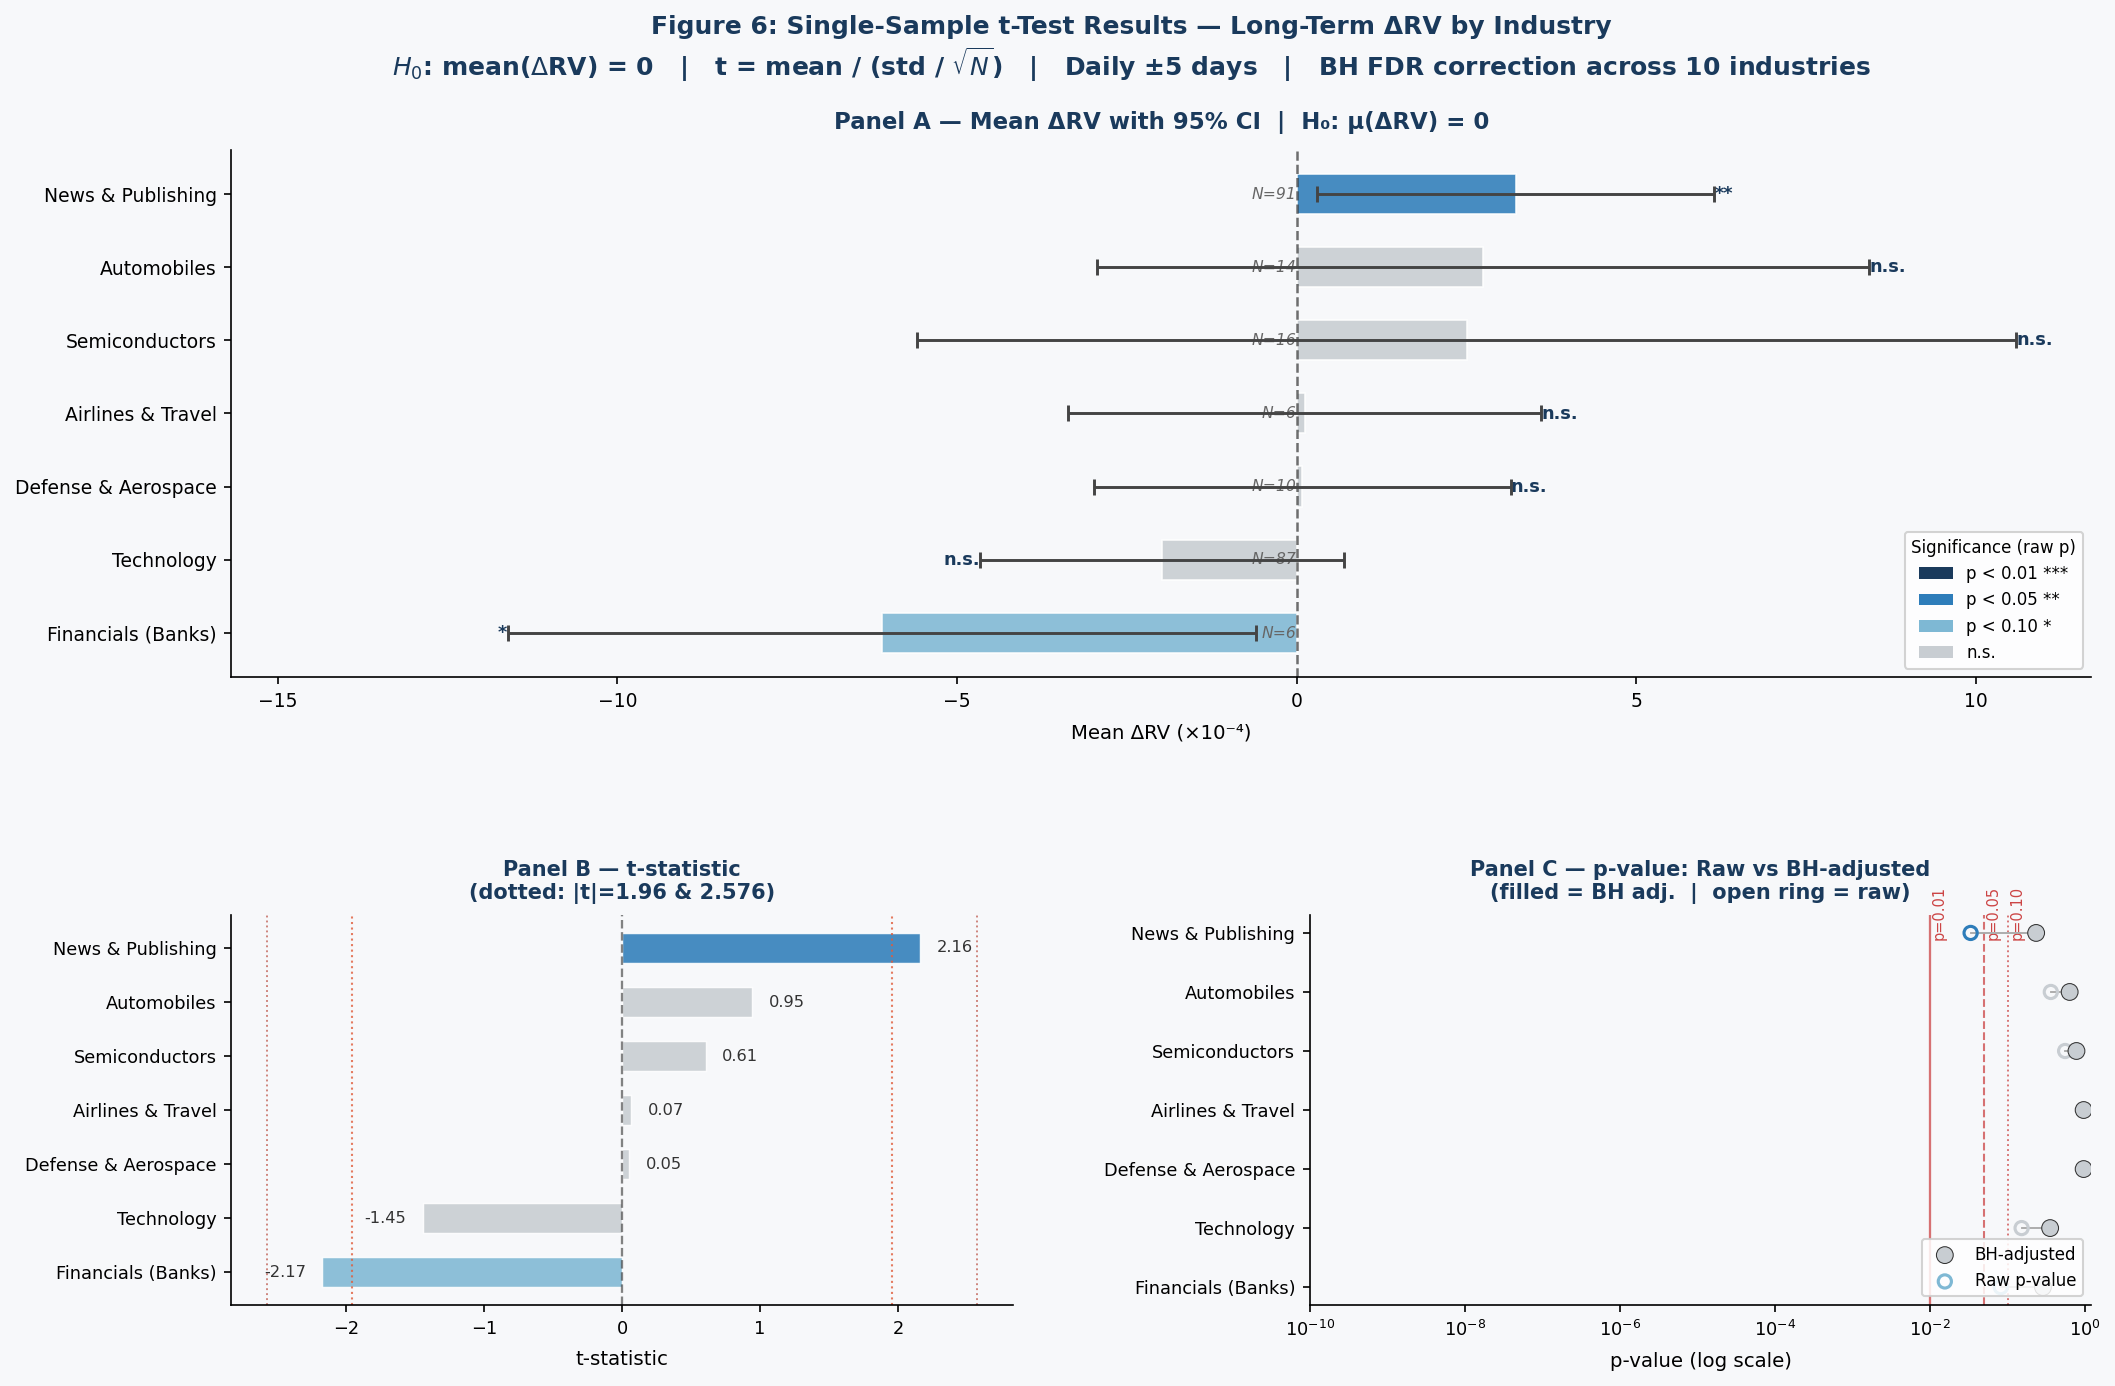

✅ Saved: /Users/summerlove/Desktop/tweet_event/plot/fig6_ttest_results_longterm.png


NameError: name 'gc' is not defined

In [ ]:
# ══════════════════════════════════════════════════════════════════
# Step 6.6 — Publication-quality plot of single-sample t-test results
#            Long-term: daily ΔRV  (±5 trading days)
# ══════════════════════════════════════════════════════════════════
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# ── Reconstruct display data ──────────────────────────────────────
ts = ttest_summary.copy()
ts = ts[ts['N'] >= 2].copy()
ts = ts.sort_values('Mean ΔRV', ascending=True)

labels   = ts.index.tolist()
n_ind    = len(labels)

mean_drv = ts['Mean ΔRV'].values * 1e4
se_drv   = ts['Std Error'].values * 1e4
t_stats  = ts['t-stat'].values
p_raw    = ts['p-value'].values
p_bh     = ts['p-value (BH adj.)'].values
ci95     = 1.96 * se_drv

# ── Colour palette (significance → dark-to-light blue + grey) ────
SIG_PALETTE = ['#1a3a5c', '#2e7dba', '#7eb8d4', '#c8cdd2']

def sig_color(p, palette):
    if pd.isna(p):  return palette[3]
    if p < 0.01:    return palette[0]
    if p < 0.05:    return palette[1]
    if p < 0.10:    return palette[2]
    return palette[3]

bar_colors = [sig_color(p, SIG_PALETTE) for p in p_raw]

# ── Figure layout ─────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10), facecolor='#f7f8fa')
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        height_ratios=[1.15, 0.85],
                        hspace=0.52, wspace=0.38)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

y     = np.arange(n_ind)
bar_h = 0.55

# ── Panel A: Mean ΔRV ± 95% CI ───────────────────────────────────
ax1.set_facecolor('#f7f8fa')
ax1.axvline(0, color='#333333', linewidth=1.2, linestyle='--', alpha=0.7)

ax1.barh(y, mean_drv, height=bar_h,
         color=bar_colors, alpha=0.88,
         edgecolor='white', linewidth=0.8)

ax1.errorbar(mean_drv, y, xerr=ci95,
             fmt='none', ecolor='#444444',
             elinewidth=1.4, capsize=4, capthick=1.4, zorder=5)

for i, (m, ci, p) in enumerate(zip(mean_drv, ci95, p_raw)):
    star = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else 'n.s.'))
    xpos = m + ci + 0.004 if m >= 0 else m - ci - 0.004
    ha   = 'left' if m >= 0 else 'right'
    ax1.text(xpos, i, star, va='center', ha=ha,
             fontsize=8.5, color='#1a3a5c', fontweight='bold')

for i, (lbl, n) in enumerate(zip(labels, ts['N'].values)):
    ax1.text(-0.003, i, f'N={int(n)}',
             va='center', ha='right', fontsize=7.5,
             color='#666666', style='italic')

ax1.set_yticks(y);  ax1.set_yticklabels(labels, fontsize=9.5)
ax1.set_xlabel('Mean ΔRV (×10⁻⁴)', fontsize=9.5, labelpad=6)
ax1.set_title('Panel A — Mean ΔRV with 95% CI  |  H₀: μ(ΔRV) = 0',
              fontsize=11, fontweight='bold', pad=10, color='#1a3a5c')
ax1.tick_params(axis='both', labelsize=9)
ax1.spines[['top','right']].set_visible(False)
ax1.set_xlim(left=min(mean_drv - ci95) * 1.35)

legend_elements = [
    mpatches.Patch(facecolor=SIG_PALETTE[0], label='p < 0.01 ***'),
    mpatches.Patch(facecolor=SIG_PALETTE[1], label='p < 0.05 **'),
    mpatches.Patch(facecolor=SIG_PALETTE[2], label='p < 0.10 *'),
    mpatches.Patch(facecolor=SIG_PALETTE[3], label='n.s.'),
]
ax1.legend(handles=legend_elements, loc='lower right',
           fontsize=8, framealpha=0.85, edgecolor='#cccccc',
           title='Significance (raw p)', title_fontsize=8)

# ── Panel B: t-statistic ─────────────────────────────────────────
ax2.set_facecolor('#f7f8fa')
ax2.axvline(0,     color='#333333', linewidth=1.1, linestyle='--', alpha=0.6)
ax2.axvline( 1.96, color='#e05c3a', linewidth=1.0, linestyle=':', alpha=0.8)
ax2.axvline(-1.96, color='#e05c3a', linewidth=1.0, linestyle=':', alpha=0.8)
ax2.axvline( 2.576, color='#b03020', linewidth=0.9, linestyle=':', alpha=0.6)
ax2.axvline(-2.576, color='#b03020', linewidth=0.9, linestyle=':', alpha=0.6)

ax2.barh(y, t_stats, height=bar_h,
         color=[sig_color(p, SIG_PALETTE) for p in p_raw],
         alpha=0.88, edgecolor='white', linewidth=0.7)

for i, t in enumerate(t_stats):
    xpos = t + 0.12 if t >= 0 else t - 0.12
    ha   = 'left' if t >= 0 else 'right'
    ax2.text(xpos, i, f'{t:.2f}',
             va='center', ha=ha, fontsize=7.8, color='#333333')

ax2.set_yticks(y);  ax2.set_yticklabels(labels, fontsize=8.5)
ax2.set_xlabel('t-statistic', fontsize=9.5, labelpad=6)
ax2.set_title('Panel B — t-statistic\n(dotted: |t|=1.96 & 2.576)',
              fontsize=10, fontweight='bold', pad=8, color='#1a3a5c')
ax2.tick_params(axis='both', labelsize=8.5)
ax2.spines[['top','right']].set_visible(False)

# ── Panel C: p-value comparison (log scale) ──────────────────────
ax3.set_facecolor('#f7f8fa')

for thresh, ls, lw, lbl in [
    (0.01, '-',  1.1, 'p=0.01'),
    (0.05, '--', 1.0, 'p=0.05'),
    (0.10, ':',  0.9, 'p=0.10'),
]:
    ax3.axvline(thresh, color='#cc4444', linewidth=lw, linestyle=ls, alpha=0.75)
    ax3.text(thresh * 1.05, n_ind - 0.2, lbl,
             fontsize=7, color='#cc4444', va='top', rotation=90)

ax3.scatter(p_bh,  y, s=65,
            color=[sig_color(p, SIG_PALETTE) for p in p_bh],
            zorder=5, label='BH-adjusted',
            marker='o', edgecolors='#333', linewidths=0.5)
ax3.scatter(p_raw, y, s=40, color='none', zorder=4,
            label='Raw p-value', marker='o',
            edgecolors=[sig_color(p, SIG_PALETTE) for p in p_raw],
            linewidths=1.5)

for i, (pr, pb) in enumerate(zip(p_raw, p_bh)):
    if not (pd.isna(pr) or pd.isna(pb)):
        ax3.plot([pr, pb], [i, i], color='#aaaaaa', linewidth=0.9, zorder=3)

ax3.set_xscale('log')
ax3.set_yticks(y);  ax3.set_yticklabels(labels, fontsize=8.5)
ax3.set_xlabel('p-value (log scale)', fontsize=9.5, labelpad=6)
ax3.set_title('Panel C — p-value: Raw vs BH-adjusted\n(filled = BH adj.  |  open ring = raw)',
              fontsize=10, fontweight='bold', pad=8, color='#1a3a5c')
ax3.tick_params(axis='both', labelsize=8.5)
ax3.spines[['top','right']].set_visible(False)
ax3.legend(fontsize=8, loc='lower right', framealpha=0.85, edgecolor='#cccccc')
ax3.set_xlim(left=1e-10)

# ── Overall title ─────────────────────────────────────────────────
fig.suptitle(
    'Figure 6: Single-Sample t-Test Results — Long-Term ΔRV by Industry\n'
    r'$H_0$: mean($\Delta$RV) = 0   |   t = mean / (std / $\sqrt{N}$)'
    '   |   Daily ±5 days   |   BH FDR correction across 10 industries',
    fontsize=12, fontweight='bold', y=0.97, color='#1a3a5c')

plt.tight_layout(rect=[0, 0, 1, 0.93])
out_path = os.path.join(PLOT_DIR, 'fig6_ttest_results_longterm.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#f7f8fa')
plt.show()
print(f"✅ Saved: {os.path.basename(out_path)}")
plt.close(); gc.collect()



---
## Figure 1: Per-Day AAV_t — 10-Industry Subplot Bar Chart

**Goal:** Show per-day $(r_t^2 - \overline{RV_{pre}})$ averaged across events,
for t ∈ [−5, +5]. Red = above pre-event level, Blue = below.

Stars indicate days with significant per-bar abnormal variance (Patell test).
Industry titles show overall ΔRV significance.

Computing per-day significance (110 Patell tests)...
  Done.


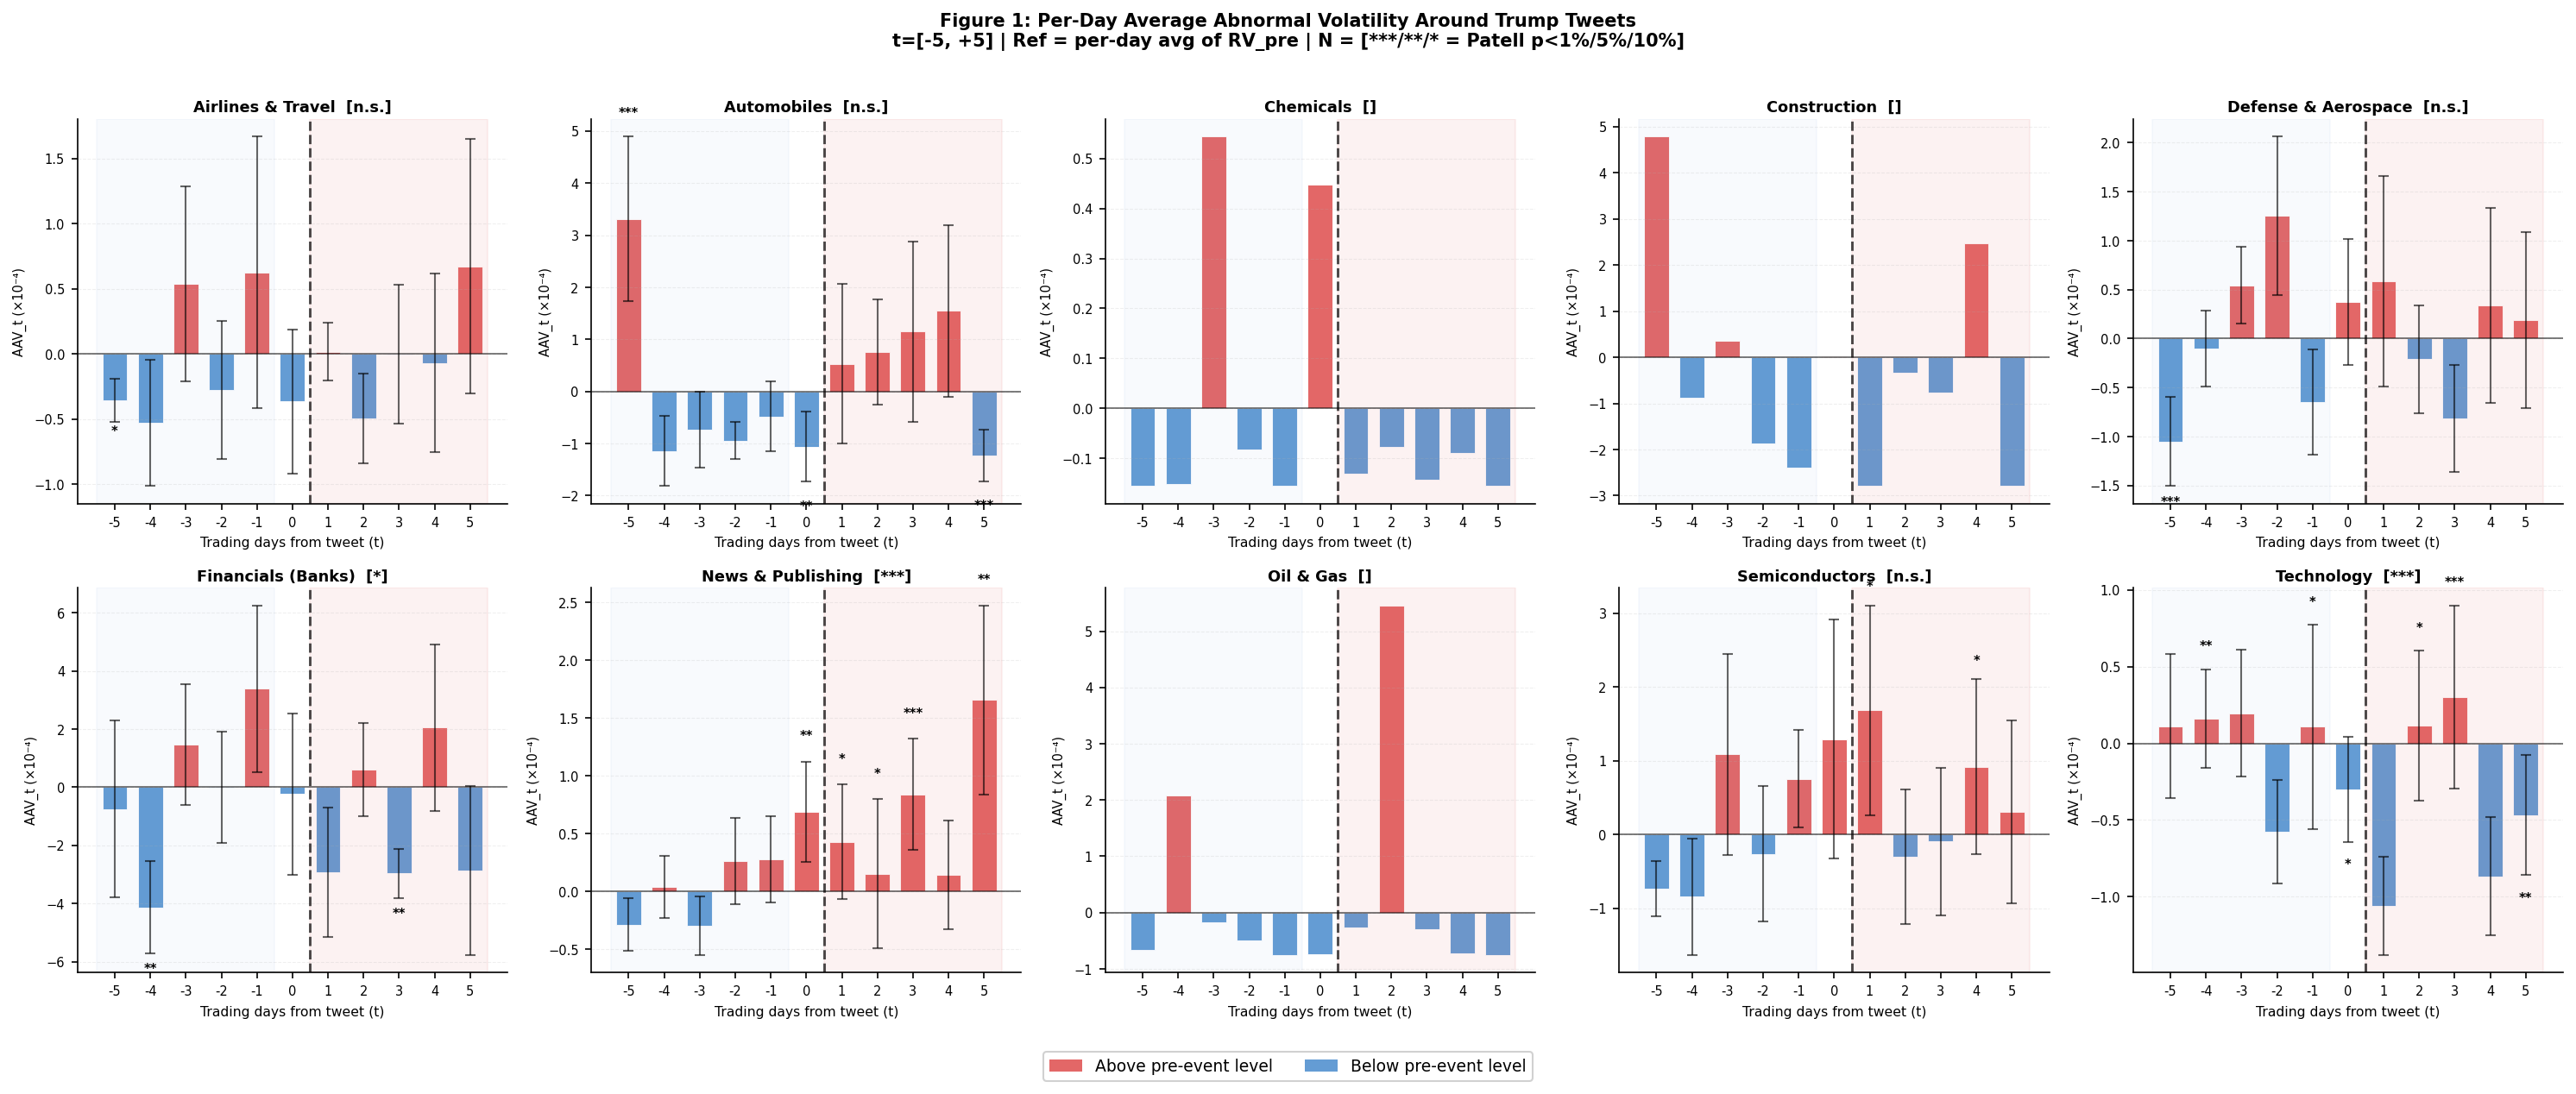

✅ Saved: /Users/summerlove/Desktop/tweet_event/plot/fig1_daily_aav_subplots.png


44661

In [ ]:
plt.close('all')
import gc; gc.collect()

def bar_patell(panels, tweet_industry_map, industry,
               pre_start=PRE_T_START, pre_end=PRE_T_END, t_point=0):
    """Patell test for a single day t_point vs pre-window per-day average."""
    std_avs = []
    for fk, df in panels.items():
        if industry not in tweet_industry_map.get(fk, []):
            continue
        if industry not in df.columns:
            continue
        r_t  = df[industry].dropna()
        rv_t = r_t ** 2
        pre  = rv_t.loc[(rv_t.index >= pre_start) & (rv_t.index <= pre_end)]
        if len(pre) == 0 or t_point not in rv_t.index:
            continue
        mu  = pre.mean()
        sig = pre.std(ddof=1)
        if sig == 0:
            continue
        std_avs.append((rv_t.loc[t_point] - mu) / sig)
    if len(std_avs) < 2:
        return np.nan, np.nan
    arr = np.array(std_avs); n = len(arr)
    t_v = arr.mean() / (arr.std(ddof=1) / np.sqrt(n))
    return t_v, 2 * stats.t.sf(abs(t_v), df=n-1)

def h_stars(p):
    if pd.isna(p): return ''
    if p < 0.01:   return '***'
    if p < 0.05:   return '**'
    if p < 0.10:   return '*'
    return ''

print("Computing per-day significance (110 Patell tests)...")
bar_pvals = {}
for ind_col in ALL_INDUSTRIES:
    for t in T_VALS:
        _, p = bar_patell(panels, tweet_industry_map, ind_col, t_point=t)
        bar_pvals[(ind_col, t)] = p
print("  Done.")

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=False)
axes_flat = axes.flatten()

fig.suptitle(
    f"Figure 1: Per-Day Average Abnormal Volatility Around Trump Tweets\n"
    f"t=[{T_MIN}, +{T_MAX}] | Ref = per-day avg of RV_pre | "
    f"N = [***/**/* = Patell p<1%/5%/10%]",
    fontsize=10, fontweight='bold', y=1.01
)

for ax_idx, (ind_col, ind_label) in enumerate(IND_MAP.items()):
    ax = axes_flat[ax_idx]
    if ind_col not in aav_df.columns:
        ax.set_visible(False); continue

    aav_vals = aav_df[ind_col].values * 1e4
    se_vals  = aav_se_df[ind_col].values * 1e4
    bar_cols = ['#e05252' if v >= 0 else '#4f8fce' for v in aav_vals]

    ax.bar(T_VALS, aav_vals, color=bar_cols,
           width=0.7, alpha=0.88, edgecolor='white', linewidth=0.5)
    ax.errorbar(T_VALS, aav_vals, yerr=se_vals,
                fmt='none', color='black', capsize=3, linewidth=1.0, alpha=0.6)

    for t, val in zip(T_VALS, aav_vals):
        p  = bar_pvals.get((ind_col, t), np.nan)
        st = h_stars(p)
        if st:
            idx  = T_VALS.index(t)
            yoff = se_vals[idx]
            mx   = abs(aav_vals).max() if abs(aav_vals).max() > 0 else 1
            ypos = (val + yoff + mx * 0.10) if val >= 0 else (val - yoff - mx * 0.18)
            ax.text(t, ypos, st, ha='center', va='bottom',
                    fontsize=7, fontweight='bold')

    # Shade post window
    ax.axvspan(POST_T_START - 0.5, T_MAX + 0.5, alpha=0.07, color='#e05252')
    ax.axvspan(T_MIN - 0.5, PRE_T_END + 0.5,   alpha=0.04, color='#4f8fce')

    ax.axhline(0, color='black', linewidth=0.8, alpha=0.6)
    ax.axvline(0.5, color='black', linewidth=1.4, linestyle='--', alpha=0.7)

    row_ts = test_summary[test_summary['industry'] == ind_col]
    sig    = row_ts['sig_patell'].iloc[0] if len(row_ts) > 0 else ''
    ax.set_title(f"{ind_label}  [{sig}]", fontsize=8.5, fontweight='bold', pad=4)
    ax.set_xlabel('Trading days from tweet (t)', fontsize=7.5)
    ax.set_ylabel('AAV_t (×10⁻⁴)', fontsize=7)
    ax.set_xticks(T_VALS)
    ax.set_xticklabels([str(t) for t in T_VALS], fontsize=7)
    ax.tick_params(axis='both', labelsize=7)
    ax.grid(axis='y', alpha=0.2, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(facecolor='#e05252', alpha=0.88, label='Above pre-event level'),
    Patch(facecolor='#4f8fce', alpha=0.88, label='Below pre-event level'),
], loc='lower center', ncol=2, fontsize=9,
   bbox_to_anchor=(0.5, -0.03), framealpha=0.9)

plt.tight_layout(rect=[0, 0.02, 1, 1])
out_path = os.path.join(PLOT_DIR, 'fig1_daily_aav_subplots.png')
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {os.path.basename(out_path)}")
plt.close(); gc.collect()


---
## Figure 2: Mean ΔRV by Industry — Sorted Bar Chart (95% CI)

**Goal:** Rank industries by mean $\Delta RV = RV_{post} - RV_{pre}$,
with BH-corrected significance stars and 95% CI error bars.

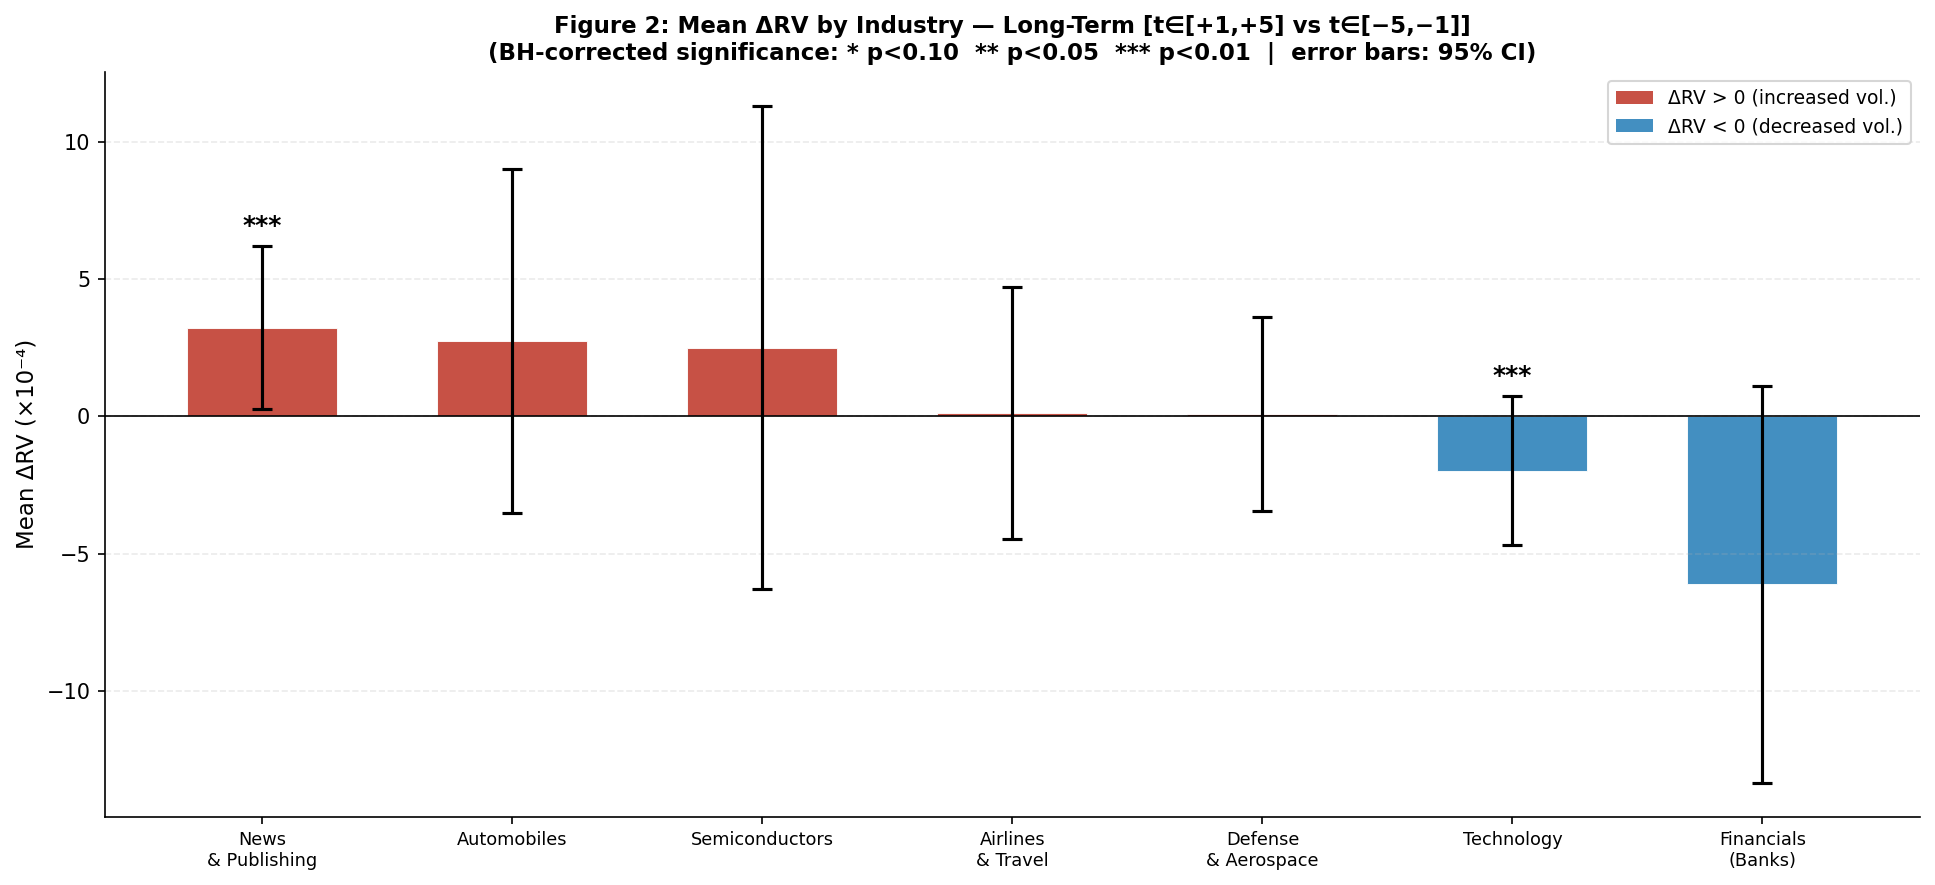

✅ Saved: /Users/summerlove/Desktop/tweet_event/plot/fig2_mean_drv_sorted_bar.png


12

In [ ]:
plt.close('all'); import gc; gc.collect()

ts2 = test_summary.reset_index().copy()
ts2 = ts2.sort_values('mean_drv', ascending=False).reset_index(drop=True)

ci_lo, ci_hi = [], []
for _, row in ts2.iterrows():
    sub = results[results['industry'] == row['industry']]['drv'].dropna()
    n = len(sub)
    if n > 1:
        se = sub.std(ddof=1) / np.sqrt(n)
        tc = stats.t.ppf(0.975, df=n-1)
        ci_lo.append(sub.mean() - tc*se)
        ci_hi.append(sub.mean() + tc*se)
    else:
        ci_lo.append(np.nan); ci_hi.append(np.nan)
ts2['ci_lo'] = ci_lo
ts2['ci_hi'] = ci_hi

fig, ax = plt.subplots(figsize=(13, 6))
bar_colors = ['#c0392b' if v >= 0 else '#2980b9' for v in ts2['mean_drv']]
x = np.arange(len(ts2))

ax.bar(x, ts2['mean_drv'] * 1e4, color=bar_colors,
       width=0.6, alpha=0.88, edgecolor='white', linewidth=0.5)

el = np.nan_to_num((ts2['mean_drv'] - ts2['ci_lo']).values * 1e4)
eu = np.nan_to_num((ts2['ci_hi']  - ts2['mean_drv']).values * 1e4)
ax.errorbar(x, ts2['mean_drv'] * 1e4, yerr=[el, eu],
            fmt='none', color='black', capsize=5, linewidth=1.5, capthick=1.5)

for i, (_, row) in enumerate(ts2.iterrows()):
    sig = row.get('sig_bh', row['sig_patell'])
    if sig and sig not in ('n.s.', ''):
        ypos = (row['ci_hi'] if not np.isnan(row['ci_hi']) else row['mean_drv']) * 1e4
        ypos += max(abs(ts2['mean_drv'].max() * 1e4) * 0.04, 0.3)
        ax.text(i, ypos, sig, ha='center', va='bottom',
                fontsize=12, fontweight='bold', color='black')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)

def fmt_lbl(s):
    for a, b in [(' & Auto Components','\n& Auto Components'),
                 (' & Aerospace',      '\n& Aerospace'),
                 (' & Publishing',     '\n& Publishing'),
                 (' & Internet',       '\n& Internet'),
                 (' & Natural Gas',    '\n& Natural Gas'),
                 (' & Travel',         '\n& Travel'),
                 (' (Banks)',          '\n(Banks)'),
                 (' & Infrastructure', '\n& Infrastructure')]:
        s = s.replace(a, b)
    return s

ax.set_xticklabels([fmt_lbl(r['label']) for _, r in ts2.iterrows()],
                   rotation=0, ha='center', fontsize=8.5)
ax.set_ylabel('Mean ΔRV (×10⁻⁴)', fontsize=11)
ax.set_title(
    'Figure 2: Mean ΔRV by Industry — Long-Term [t∈[+1,+5] vs t∈[−5,−1]]\n'
    '(BH-corrected significance: * p<0.10  ** p<0.05  *** p<0.01  |  error bars: 95% CI)',
    fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#c0392b', alpha=0.88, label='ΔRV > 0 (increased vol.)'),
    Patch(facecolor='#2980b9', alpha=0.88, label='ΔRV < 0 (decreased vol.)'),
], loc='upper right', fontsize=9)

plt.tight_layout()
out_path = os.path.join(PLOT_DIR, 'fig2_mean_drv_sorted_bar.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {os.path.basename(out_path)}")
plt.close(); gc.collect()


---
## Figure 3: ΔRV Distribution by Industry (Box Plot)

**Goal:** Show the full event-level distribution of $\Delta RV$ per industry.
Clip y-axis to 2nd–98th percentile to suppress extreme outlier distortion.

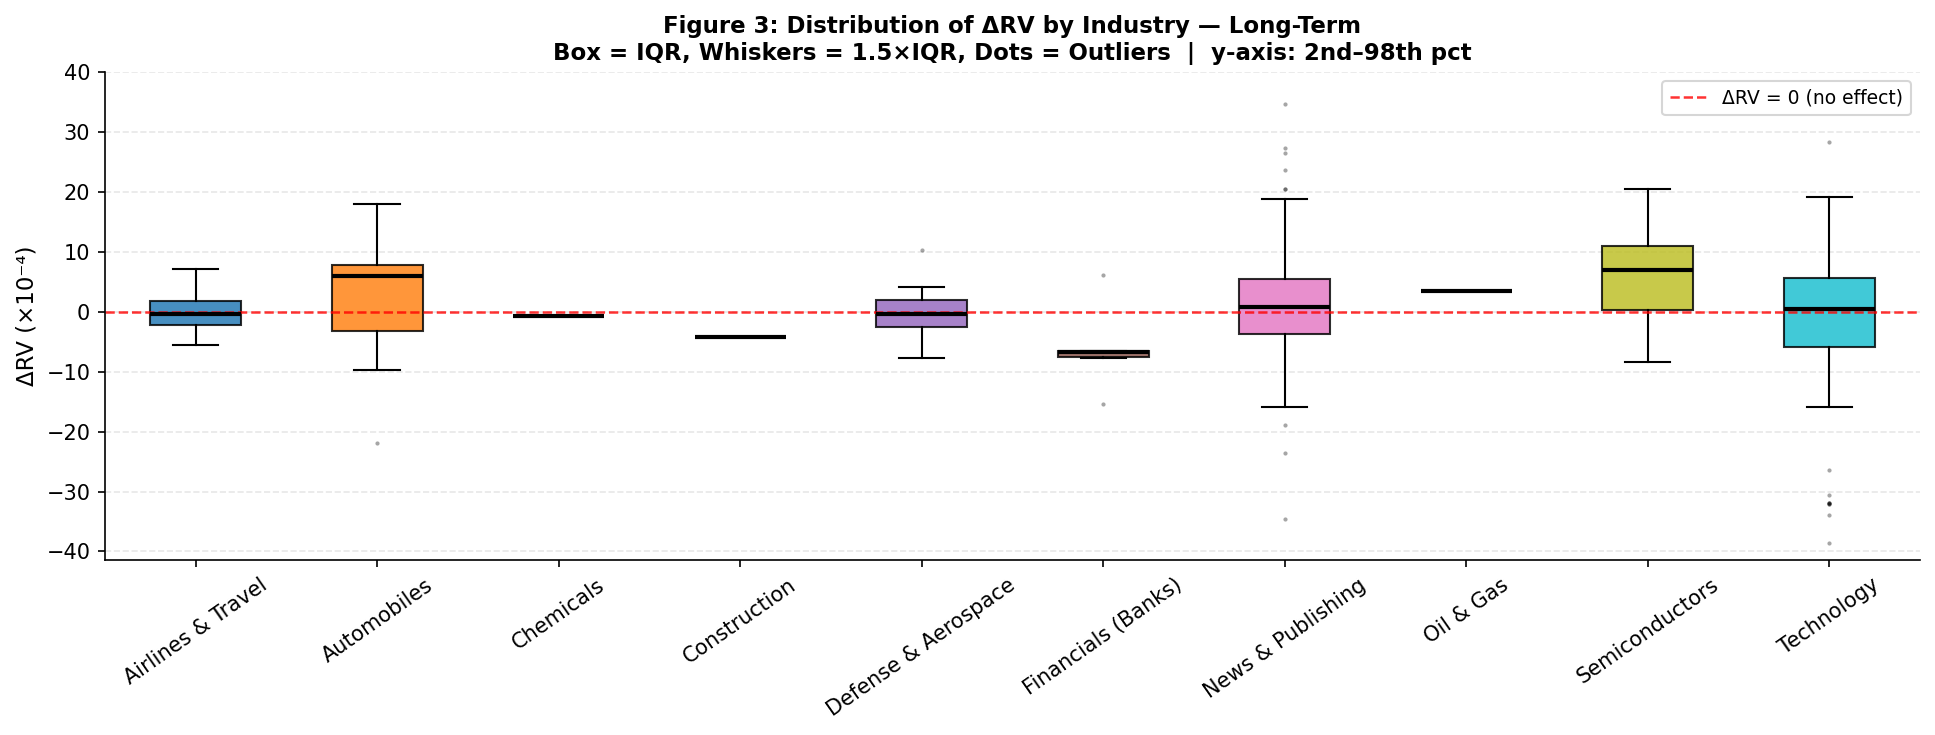

✅ Saved: /Users/summerlove/Desktop/tweet_event/plot/fig3_boxplot_drv_longterm.png


11999

In [ ]:
plt.close('all'); import gc; gc.collect()

fig, ax = plt.subplots(figsize=(13, 5))
plot_data  = [results[results['industry']==ind]['drv'].dropna().values * 1e4
              for ind in ALL_INDUSTRIES]
short_lbls = [IND_MAP[ind] for ind in ALL_INDUSTRIES]

bp = ax.boxplot(plot_data, labels=short_lbls,
                patch_artist=True, notch=False,
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='.', markersize=2, alpha=0.35),
                boxprops=dict(alpha=0.82),
                whiskerprops=dict(linewidth=1),
                capprops=dict(linewidth=1))

for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)

# Clip y-axis to 2nd–98th percentile
all_vals = np.concatenate([d for d in plot_data if len(d) > 0])
y_lo = np.nanpercentile(all_vals, 2)
y_hi = np.nanpercentile(all_vals, 98)
margin = (y_hi - y_lo) * 0.15
ax.set_ylim(y_lo - margin, y_hi + margin)

ax.axhline(0, color='red', linestyle='--', linewidth=1.2, alpha=0.8,
           label='ΔRV = 0 (no effect)')
ax.set_ylabel('ΔRV (×10⁻⁴)', fontsize=11)
ax.set_title(
    'Figure 3: Distribution of ΔRV by Industry — Long-Term\n'
    'Box = IQR, Whiskers = 1.5×IQR, Dots = Outliers  |  y-axis: 2nd–98th pct',
    fontsize=11, fontweight='bold')
ax.tick_params(axis='x', rotation=35)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
out_path = os.path.join(PLOT_DIR, 'fig3_boxplot_drv_longterm.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {os.path.basename(out_path)}")
plt.close(); gc.collect()


---
## Figure 5: Per-Day AAV_t Heatmap — All Industries × 11 Bars

**Goal:** Colour heatmap of the full 10-industry × 11-day AAV matrix.
Reveals which industry and which day shows the strongest reaction.

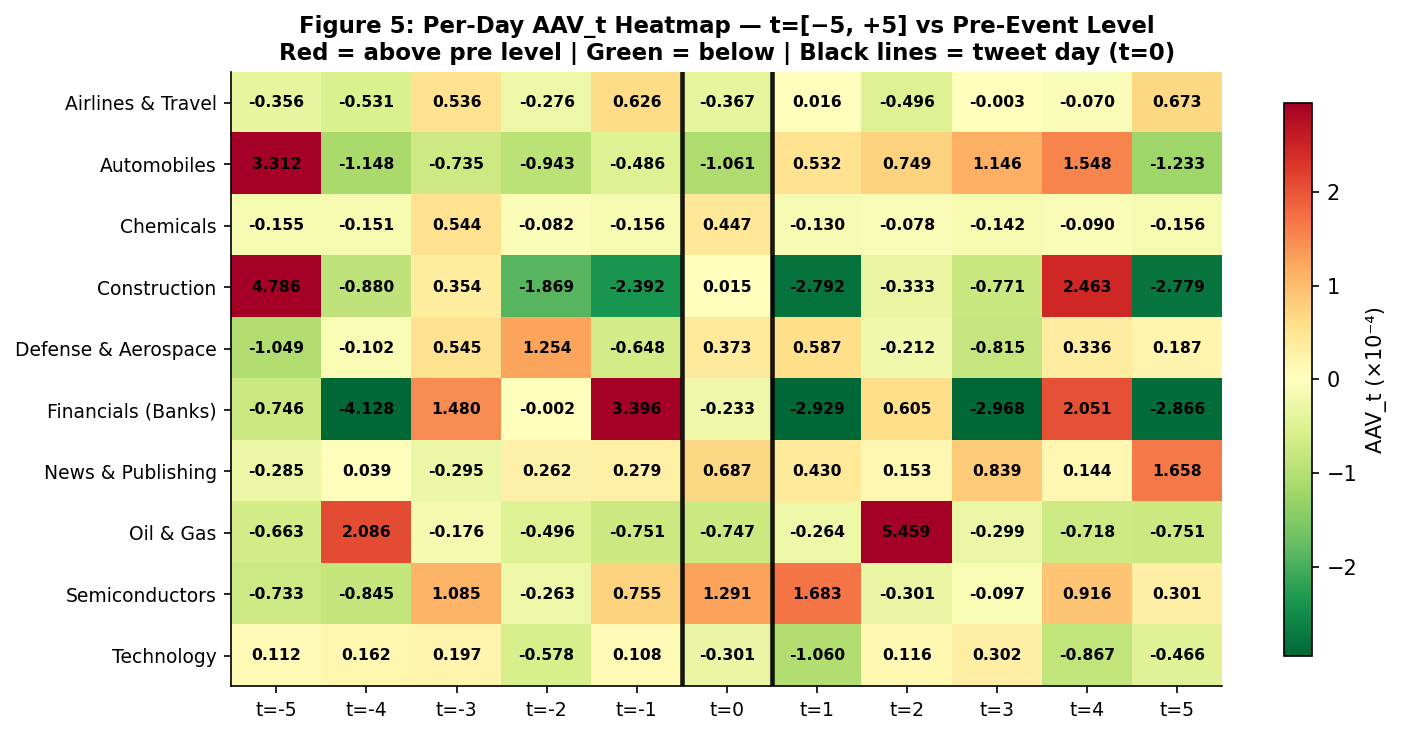

✅ Saved: /Users/summerlove/Desktop/tweet_event/plot/fig5_heatmap_aav_daily.png


11967

In [ ]:
plt.close('all'); import gc; gc.collect()

heatmap_data = aav_df.rename(columns=IND_MAP).T * 1e4   # (10 industries) × (11 days)

fig, ax = plt.subplots(figsize=(10, 5))
vmax = np.nanpercentile(np.abs(heatmap_data.values), 95)
im   = ax.imshow(heatmap_data.values, aspect='auto', cmap='RdYlGn_r',
                 vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(T_VALS)))
ax.set_xticklabels([f't={t}' for t in T_VALS], fontsize=9)
ax.set_yticks(range(len(IND_LABELS)))
ax.set_yticklabels(IND_LABELS, fontsize=9)

# Annotate each cell with value
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=7.5, color='black', fontweight='bold')

# Dividers around t=0 (tweet day excluded from both windows)
t0_idx = T_VALS.index(0)
ax.axvline(t0_idx - 0.5, color='black', linewidth=2.2, alpha=0.9)
ax.axvline(t0_idx + 0.5, color='black', linewidth=2.2, alpha=0.9)

plt.colorbar(im, ax=ax, label='AAV_t (×10⁻⁴)', shrink=0.9)
ax.set_title(
    'Figure 5: Per-Day AAV_t Heatmap — t=[−5, +5] vs Pre-Event Level\n'
    'Red = above pre level | Green = below | Black lines = tweet day (t=0)',
    fontsize=11, fontweight='bold')

plt.tight_layout()
out_path = os.path.join(PLOT_DIR, 'fig5_heatmap_aav_daily.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {os.path.basename(out_path)}")
plt.close(); gc.collect()


---
## Final Summary

In [ ]:
print('=' * 76)
print('  TRUMP TWEET EVENT STUDY — LONG-TERM DAILY SUMMARY')
print('=' * 76)
print(f'  Events loaded     : {len(panels)} daily panels')
print(f'  Industries        : {N_IND}')
print(f'  Resolution        : Daily bars  (t = trading-day offset from tweet day)')
print(f'  Pre window        : t=[{PRE_T_START}, {PRE_T_END}]  ({abs(PRE_T_START)} days)  → RV_pre  = Σ r²')
print(f'  Post window       : t=[+{POST_T_START}, +{POST_T_END}]  ({POST_T_END} days)  → RV_post = Σ r²')
print(f'  Effect measure    : ΔRV = RV_post − RV_pre  (cumulative, symmetric)')
print(f'  Primary test      : Patell (1976) standardized t-test')
print(f'  Robustness        : Wilcoxon, OLS HC3, BH FDR correction')
print('=' * 76)

ts = test_summary.reset_index()
sig_pos = ts[(ts['p_patell'] < 0.10) & (ts['mean_drv'] > 0)]
sig_neg = ts[(ts['p_patell'] < 0.10) & (ts['mean_drv'] < 0)]
nsig    = ts[ts['p_patell'] >= 0.10]

if len(sig_pos) > 0:
    print('\n  📈 SIGNIFICANT POSITIVE ΔRV (tweet INCREASED volatility):')
    for _, r in sig_pos.sort_values('mean_drv', ascending=False).iterrows():
        print(f"     {r['label']:<30}  ΔRV={r['mean_drv']*1e4:.4f}×10⁻⁴  "
              f"N={int(r['n_events'])}  t={r['t_patell']:.2f}  "
              f"p={r['p_patell']:.4f} {r['sig_patell']}")

if len(sig_neg) > 0:
    print('\n  📉 SIGNIFICANT NEGATIVE ΔRV (tweet DECREASED volatility):')
    for _, r in sig_neg.sort_values('mean_drv').iterrows():
        print(f"     {r['label']:<30}  ΔRV={r['mean_drv']*1e4:.4f}×10⁻⁴  "
              f"N={int(r['n_events'])}  t={r['t_patell']:.2f}  "
              f"p={r['p_patell']:.4f} {r['sig_patell']}")

if len(nsig) > 0:
    print('\n  ➖ NO SIGNIFICANT EFFECT:')
    for _, r in nsig.iterrows():
        print(f"     {r['label']:<30}  N={int(r['n_events'])}  "
              f"p={r['p_patell']:.4f}  n.s.")

print('\n  Significance: * p<0.10  ** p<0.05  *** p<0.01 (two-tailed, Patell)')
print('=' * 76)


  TRUMP TWEET EVENT STUDY — LONG-TERM DAILY SUMMARY
  Events loaded     : 233 daily panels
  Industries        : 10
  Resolution        : Daily bars  (t = trading-day offset from tweet day)
  Pre window        : t=[-5, -1]  (5 days)  → RV_pre  = Σ r²
  Post window       : t=[+1, +5]  (5 days)  → RV_post = Σ r²
  Effect measure    : ΔRV = RV_post − RV_pre  (cumulative, symmetric)
  Primary test      : Patell (1976) standardized t-test
  Robustness        : Wilcoxon, OLS HC3, BH FDR correction

  📈 SIGNIFICANT POSITIVE ΔRV (tweet INCREASED volatility):
     News & Publishing               ΔRV=3.2231×10⁻⁴  N=91  t=3.89  p=0.0002 ***

  📉 SIGNIFICANT NEGATIVE ΔRV (tweet DECREASED volatility):
     Financials (Banks)              ΔRV=-6.1076×10⁻⁴  N=6  t=-2.06  p=0.0950 *
     Technology                      ΔRV=-1.9760×10⁻⁴  N=87  t=3.12  p=0.0024 ***

  ➖ NO SIGNIFICANT EFFECT:
     Airlines & Travel               N=6  p=0.5324  n.s.
     Automobiles                     N=14  p=0.1228  n.

---
## Appendix: Methodological Notes

### Core Formula

$$RV_{pre}  = \sum_{d=-5}^{-1} r_d^2 \qquad
RV_{post} = \sum_{d=+1}^{+5} r_d^2 \qquad
\Delta RV = RV_{post} - RV_{pre}$$

Both windows are **cumulative sums** of squared daily returns.
t=0 (tweet day) is excluded from both windows to avoid contamination.

### Design Rationale
- **Symmetric windows:** pre and post each span 5 trading days (~1 calendar week),
  making $\Delta RV$ a clean difference without scaling ambiguity.
- **Daily resolution:** captures the multi-day persistence of the volatility
  response — whether impact decays quickly or sustains over the week.
- **Cumulative (not average):** cumulative sums preserve total variance magnitude,
  making $\Delta RV$ directly interpretable as net change in realized variance.

### t=0 Assignment
| Scenario | Assignment |
|---|---|
| Tweet during 09:30–16:00 ET on weekday | Trading day of tweet |
| Tweet after 16:00 ET | Next trading day |
| Tweet on weekend or holiday | Next trading day |

### Patell Standardization
For each event $e$, $\Delta RV_e$ is standardized by the cross-day std of $RV_{pre,e}$:

$$\hat{\Delta RV}_e = \frac{\Delta RV_e}{\sigma(r_d^2,\; d \in [-5,-1])}$$

This accounts for heteroskedasticity across events (high-volatility weeks have
larger $|\Delta RV|$ by construction; standardization corrects this).